In [2]:
import csv
import matplotlib.pyplot as plt

infile = open("../data/unlinked_bicores/50Msample_1MHz_power_on_and_touch_stripped.csv", 'r')


reader = csv.DictReader(infile)
times = []
logic0 = []
logic1 = []
for entry in reader:
    times.append(entry["microseconds"])
    logic0.append(entry["logic0"])
    logic1.append(entry["logic1"])

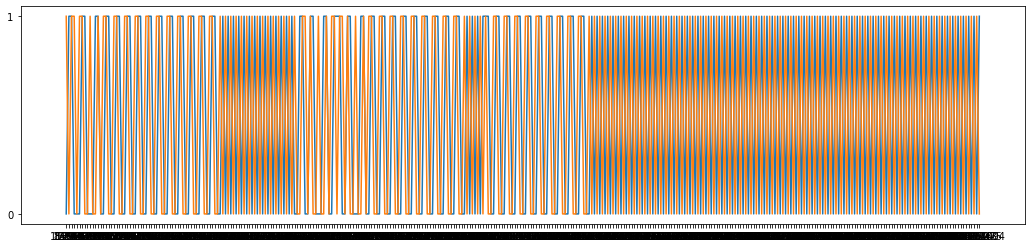

In [3]:
plt.figure(figsize=(18,4))
plt.plot(times, logic0, logic1)

The stripped version of the csv files only keeps the entries where one of the values changed, so the rising and falling edges look like slopes instead of a square wave. One way to handle that would be to fill in the data that was stripped and use the filled in version to produce the graphs. 

The other is to not really worry about the graphs immediately. One thing to look at is the frequency of each of the two waves, another is to figure out the phase relationship between the two square waves. My suspicion is that the phase is 180 degrees, which is weird given that the two bicores are not supposed to be connected. 

So how do you measure the phase difference of two square waves? Phase is the relative displacement between two waves with respect to one another. The time difference of the waves can be said to be the difference between two successive rising edges. Assuming they are the same frequency, the phase difference is the time difference between two rising edges, divided by the time of one cycle (so distance into the cycle as a ratio), multiplied by $2\pi$ to get a phase angle. 

Given the data I have, I'd have to find the frequency for both channels. Then I'd find the first rising edge in either of the channels, then the next (chronologically) rising edge in the other channel, get the difference, and then the ratio based on the frequency and calculate the phase angle. Repeat that for each set of subsequent rising edges, and then graph the results.  

Mean period: 212799.51111111112 microseconds
Standard dev: 25881.639606666213
Mean frequency: 4.699258916426082 Hz


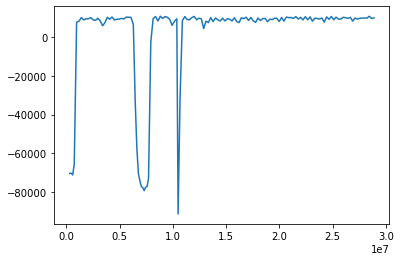

In [4]:
prev_v = None
rising_times = []
for t, v in zip(times, logic1):
    if prev_v is None:
        prev_v = v
    # Rising edges
    if prev_v != v and v == '1':
        rising_times.append(int(t))
    prev_v = v

starts = rising_times[1:]
ends = rising_times[:-1]
delta_t = [s - e for s, e in zip(starts, ends)]

import statistics
print(f"Mean period: {statistics.mean(delta_t)} microseconds")
print(f"Standard dev: {statistics.stdev(delta_t)}")
print(f"Mean frequency: {1e6/statistics.mean(delta_t)} Hz")

plt.plot(starts, [d - statistics.mean(delta_t) for d in delta_t])

Mean period: 224107.83720930232 microseconds
Standard dev: 3180.2553695386873
Mean frequency: 4.462137569361594 Hz


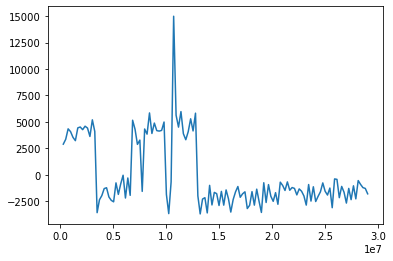

In [5]:
prev_v = None
rising_times = []
for t, v in zip(times, logic0):
    if prev_v is None:
        prev_v = v
    # Rising edges
    if prev_v != v and v == '1':
        rising_times.append(int(t))
    prev_v = v

starts = rising_times[1:]
ends = rising_times[:-1]
delta_t = [s - e for s, e in zip(starts, ends)]

import statistics
print(f"Mean period: {statistics.mean(delta_t)} microseconds")
print(f"Standard dev: {statistics.stdev(delta_t)}")
print(f"Mean frequency: {1e6/statistics.mean(delta_t)} Hz")

plt.plot(starts, [d - statistics.mean(delta_t) for d in delta_t])

This system had two ostensibly unlinked bicores, but they had about the same frequency, ~4.3Hz, so it makes some sense to talk about having phase as a major component of their relationship.  

130 84693
136 159141
[-74448, 10253, 95257, 182183, 263309, 270420, 276651, 282258, 289117, 295145, 301524, 307114, 313050, 320834, 326404, 325701, 328735, 330535, 330205, 330974, 329717, 329665, 329151, 330312, 330024, 331018, 331889, 330663, 331387, 334225, 384399, 457673, 542474, 631340, 718305, 811742, 906281, 1001063, 1093507, 1182717, 1200666, 1206450, 1211227, 1219103, 1217695, 1215614, 1215589, 1231564, 1239282, 1248978, 1257995, 1263618, 1369680, 1417014, 1425054, 1429828, 1437830, 1438105, 1435562, 1433803, 1433934, 1431804, 1432605, 1436568, 1437889, 1439845, 1438090, 1439731, 1438218, 1439060, 1439725, 1437614, 1438140, 1438285, 1439146, 1439905, 1439349, 1440921, 1441460, 1439785, 1439884, 1437946, 1439230, 1437792, 1437060, 1439903, 1438645, 1440400, 1440037, 1439085, 1440676, 1439834, 1441358, 1441775, 1441848, 1444356, 1444004, 1445769, 1445344, 1444618, 1444380, 1444404, 1443039, 1442054, 1442189, 1442060, 1441590, 1441341, 1440074, 1441467, 1442136, 1442225, 1442169, 

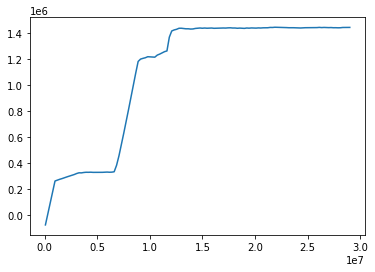

In [6]:
prev_v = None
l0_rising_times = []
l1_rising_times = []
for t, v in zip(times, logic0):
    if prev_v is None:
        prev_v = v
    # Rising edges
    if prev_v != v and v == '1':
        l0_rising_times.append(int(t))
    prev_v = v

prev_v = None
for t, v in zip(times, logic1):
    if prev_v is None:
        prev_v = v
    # Rising edges
    if prev_v != v and v == '1':
        l1_rising_times.append(int(t))
    prev_v = v

print(len(l0_rising_times), l0_rising_times[0])
print(len(l1_rising_times), l1_rising_times[0])

# logic1 had more rising edges, so drop one
diff = [l0r - l1r for l1r, l0r in zip(l1_rising_times, l0_rising_times)]
print(diff)
plt.plot(l0_rising_times, diff)

That appears to be a pretty linear rise over the first 20 or so samples. This is handling one of the smaller datasets, 5Msamples at 1Mhz, so 5 seconds of data (at 4 Hz, so about 20 actual rising edges). If the signals were actually 180 degrees out of phase, the difference would top out around the period, which was 228706us or so. 

If they are falling into sync after power-up, the 50Msample datasets would show the leveling off. Going to duplicate this notebook, change the input file, and rerun. 

A problem arises when one of the signals is not of consistent frequency. At that point, the use of rising edges doesn't make sense for measurement of phase angle because there isn't a 1-to-1 correspondance of rising edges. 

I can pretty much graph "instantaneous frequency" based on the distance between subsequent rising edges, and only look at sections where the frequencies are approximately the same. The thing I'm trying to figure out here is whether the two bicores are falling into synchrony despite being disconnected, but in a rigorous way, rather than looking at pictures. 